# Truncated Normal Distribution

`TruncatedNormal(mean, sd, a, b)` is a normal distribution restricted to the interval `[a, b]`: any value that would fall outside the interval is discarded, and the remaining bell curve is rescaled so its area is again 1.

In [11]:
from symbulate import *

## Draw a value

Every draw lands inside the truncation interval.

In [12]:
TruncatedNormal(mean=0, sd=1, a=-2, b=2).draw()

-1.0356783485519112

## Theoretical mean, variance, and standard deviation

The `mean` argument is the center of the *underlying* normal, not of the truncated distribution. When the truncation is lopsided the actual mean is pulled toward the interval. Here `TruncatedNormal(mean=0, sd=1, a=0)` keeps only the positive half of a standard normal, so its mean is well above 0 (it is exactly the half-normal mean, `sqrt(2 / pi)`).

In [13]:
TruncatedNormal(mean=0, sd=1, a=0).mean(), TruncatedNormal(mean=0, sd=1, a=0).var(), TruncatedNormal(mean=0, sd=1, a=0).sd()

(np.float64(0.7978845608028654),
 np.float64(0.3633802276324186),
 np.float64(0.6028102749890869))

## Assign and simulate a random variable

In [14]:
T = RV(TruncatedNormal(mean=0, sd=1, a=-2, b=2))
T.sim(10000)

0,0.43396838494770484
1,0.35429362964582595
2,-1.9575290175288673
3,1.049549737761366
4,0.4484746193649702
5,-0.6222179011088192
6,0.7704361413738734
7,0.12693857563943525
8,1.7896471574300972
...,...
9999,-0.7221424157095887


## Plot the pdf

The density is the middle of a normal bell curve, cut off sharply at `a` and `b` and lifted so the area still totals 1. The vertical edges at the bounds are the hallmark of a truncated distribution.

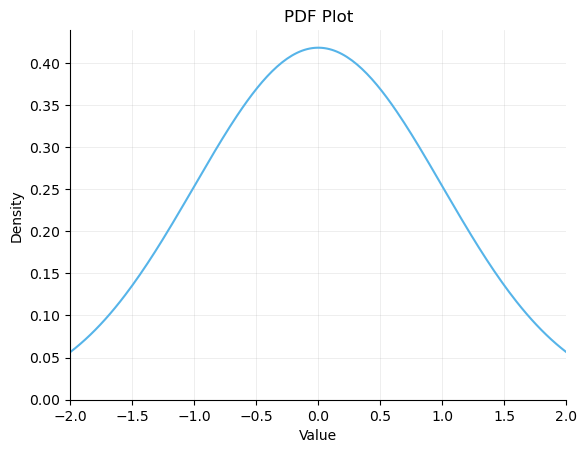

In [15]:
TruncatedNormal(mean=0, sd=1, a=-2, b=2).plot()

## Plot the CDF

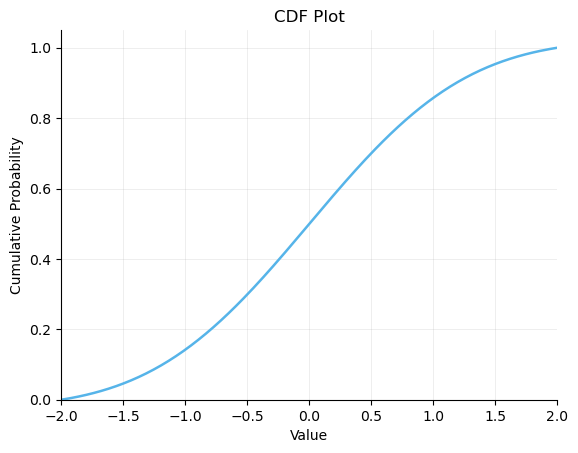

In [16]:
TruncatedNormal(mean=0, sd=1, a=-2, b=2).plot(cdf=True)

## Tighter bounds mean a taller curve

As the interval narrows, less of the bell is kept, so the surviving piece must rise higher to keep its area at 1.

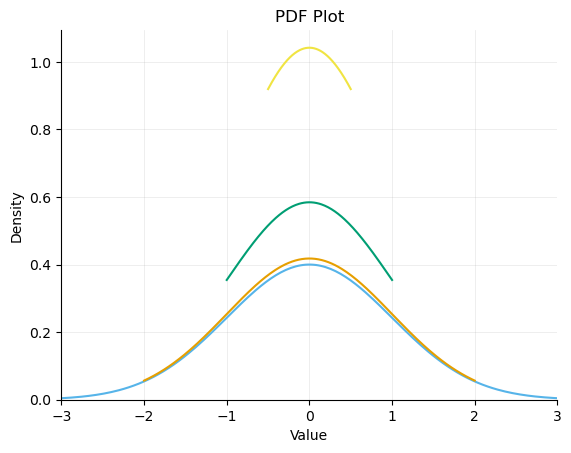

In [17]:
for bound in [3, 2, 1, 0.5]:
    TruncatedNormal(mean=0, sd=1, a=-bound, b=bound).plot()

## Relationship: truncating below the mean gives a half-normal

Keeping only the values of a `Normal(0, 1)` at or above its mean -- `TruncatedNormal(mean=0, sd=1, a=0)` -- is exactly the `HalfNormal(scale=1)`.

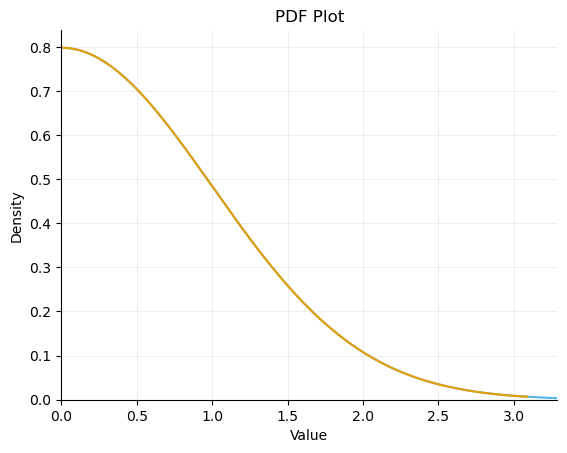

In [18]:
TruncatedNormal(mean=0, sd=1, a=0).plot()
HalfNormal(scale=1).plot()

## Relationship: no truncation recovers the normal

Leaving both bounds off (the defaults `-inf` and `+inf`) discards nothing, so `TruncatedNormal(mean=2, sd=3)` is just `Normal(mean=2, sd=3)`.

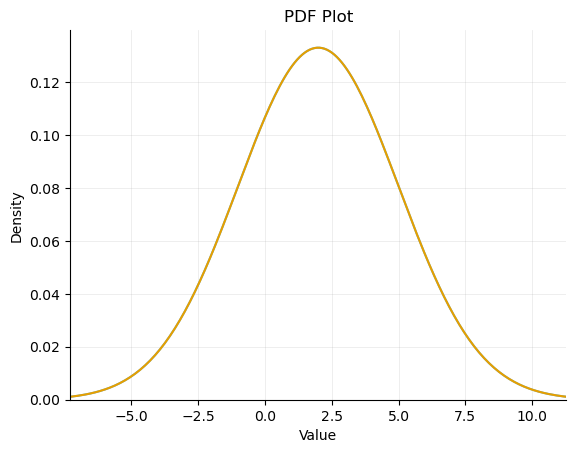

In [19]:
TruncatedNormal(mean=2, sd=3).plot()
Normal(mean=2, sd=3).plot()